In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
waka_dragon_df = pd.read_csv("data/waka_dragon_merged.csv")
waka_dragon_df

,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,AMW,Sv,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,6.294,7.537,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
1,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,7.581,9.295,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
2,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,6.759,9.822,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
3,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,8.597,12.010,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
4,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,6.444,13.876,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,16070752,117933-89-8,karanal,48.88,-1.32,0.50,1,266.47,5.438,26.332,...,164.119,292.88,0.873,-4.57,-4.87,-4.97,2.0,98.0,0.016,0.0
308,16204527,1335-66-6,isocyclocitral,59.65,1.38,0.66,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
309,19871663,1247790-47-1,terpirosa,36.61,1.48,0.66,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
310,44153588,113889-23-9,tricyclodecenyl butyrate,24.15,-0.51,0.11,0,220.34,6.121,20.698,...,125.021,225.98,0.930,-4.19,-4.44,-4.52,6.0,88.0,0.021,0.0


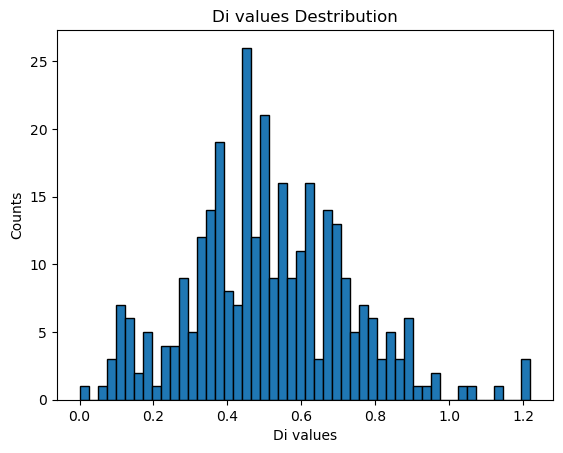

In [3]:
# distribution of Di in whole waka data set
plt.hist(waka_dragon_df['Di_x'], bins=50, edgecolor = 'k')
plt.xlabel('Di values')
plt.ylabel("Counts")
plt.title('Di values Destribution')
plt.show()

In [4]:
print(f"The number of rows without Dragon descriptors: {waka_dragon_df.isna().any(axis=1).sum()}")

The number of rows without Dragon descriptors: 24


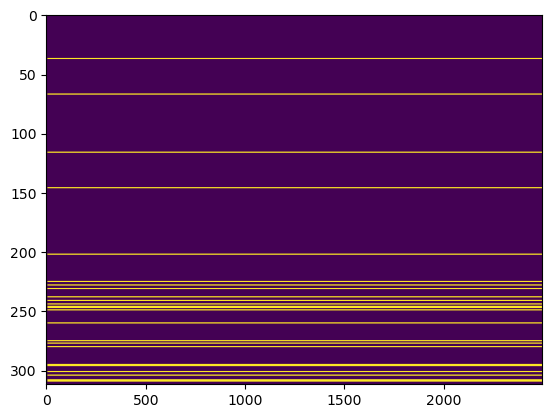

In [5]:
plt.imshow(waka_dragon_df.isna(), aspect='auto', interpolation=None)

In [6]:
valid_mask = ~waka_dragon_df.isna().any(axis=1)
waka_dragon_df = waka_dragon_df.loc[valid_mask, :]
print(f"Dimension of waka_dragon_df after dropping ow rows: {waka_dragon_df.shape}")

Dimension of waka_dragon_df after dropping ow rows: (288, 2497)


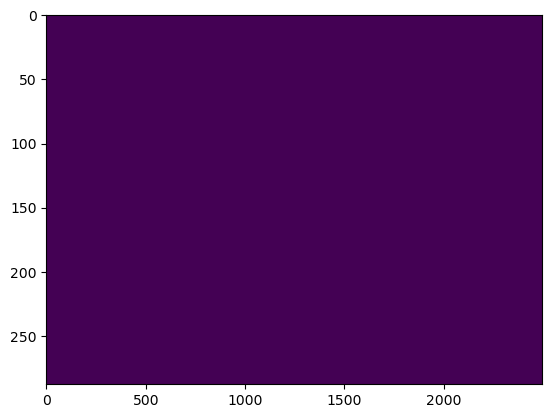

In [7]:
plt.imshow(waka_dragon_df.isna(), aspect='auto', interpolation=None)

In [8]:
mX_df = waka_dragon_df.loc[:, 'MW' :]
vY = waka_dragon_df['Di_x']
vY


0      0.76
1      0.69
2      0.33
3      0.77
4      0.47
       ... 
305    0.63
306    0.22
307    0.50
310    0.11
311    0.73
Name: Di_x, Length: 288, dtype: float64

In [9]:
#first we remove features with zero variance
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0) #object 

mX1 = vt.fit_transform(mX_df) #returns NDArray

# mX1_df becomes the updated feature matrix
mX1_df = pd.DataFrame(
    mX1,
    columns=mX_df.columns[vt.get_support()],
    index=mX_df.index
)

print(mX1_df.shape)

(288, 2484)


In [10]:
# correlations matrix
corr_matrix = mX1_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95) # May be the correlation threshold should be lower
]

print(f"Descriptors to remove: {len(to_drop)}")

Descriptors to remove: 1650


In [11]:
# Dropping of high correlated descriptors
mX2_df = mX1_df.drop(columns=to_drop)
print(mX2_df.shape)

(288, 834)


In [12]:
n_cols_with_nan = mX2_df.isna().any(axis=0).sum()

print(f"Columns containing NaN: {n_cols_with_nan}")
print(f"Total columns: {mX2_df.shape[1]}")

Columns containing NaN: 0
Total columns: 834


In [13]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold

In [14]:
xgb = XGBRegressor(
    objective="reg:absoluteerror",
    learning_rate=0.03,
    max_depth=2,
    n_estimators=800,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
)

In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [16]:
from sklearn.dummy import DummyRegressor

dummy_reg = DummyRegressor(strategy='mean')
y_pred_dummy = cross_val_predict(
    dummy_reg,
    mX2_df,
    vY,
    cv=cv
)
mae_dummy = mean_absolute_error(vY, y_pred_dummy)
r2_dummy = r2_score(vY, y_pred_dummy)

print(f"MAE = {mae_dummy:.3f}")
print(f"R²  = {r2_dummy:.3f}")

MAE = 0.171
R²  = -0.004


In [17]:
vY_pred_init = cross_val_predict(estimator=xgb, X=mX2_df, y=vY, cv=cv, n_jobs=-1, verbose=4)
mae_init = mean_absolute_error(vY, vY_pred_init)
print(mae_init)
r2_init = r2_score(vY, vY_pred_init)
print(r2_init)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    5.6s remaining:    8.5s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.7s finished


0.1458823567794429
0.2835172506355055


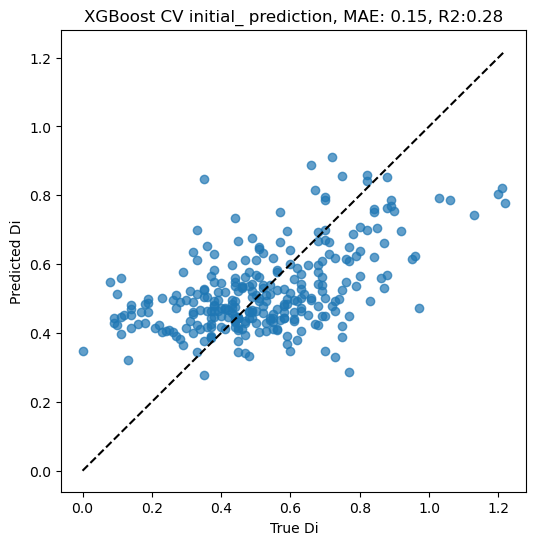

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(vY, vY_pred_init, alpha=0.7)

plt.plot(
    [vY.min(), vY.max()],
    [vY.min(), vY.max()],
    '--k'
)

plt.xlabel("True Di")
plt.ylabel("Predicted Di")
plt.title(f"XGBoost CV initial_ prediction, MAE: {mae_init:.2f}, R2:{r2_init:.2f}")

plt.show()

In [19]:
xgb.fit(mX2_df, vY)
importance = pd.Series(
    xgb.feature_importances_,
    index= mX2_df.columns
).sort_values(ascending=False)

importance.head(60)

MPC08             0.005077
SM12_AEA_dm_      0.004696
SM05_AEA_dm_      0.003817
GGI6              0.003663
SpMaxA_AEA_dm_    0.003438
Wap               0.003393
ZM1Mad            0.003028
MPC07             0.002842
P_VSA_s_6         0.002798
GGI5              0.002692
ZM2               0.002622
HATS4m            0.002586
RDF090u           0.002543
Mor31s            0.002504
MATS1v            0.002474
RDF080u           0.002461
H2m               0.002441
Mor06v            0.002433
RDF050m           0.002424
R3u               0.002400
SpMaxA_B_s_       0.002370
R3m_              0.002341
GATS1p            0.002302
Eig05_AEA_dm_     0.002302
RTm               0.002298
G1v               0.002228
P_VSA_ppp_ter     0.002221
VE1_A             0.002208
AVS_B_m_          0.002175
TDB05v            0.002173
RDF100s           0.002139
SM07_EA_dm_       0.002121
GATS3v            0.002114
HATS1u            0.002105
RDF080m           0.002105
SHP2              0.002086
Mor11v            0.002077
A

In [20]:
results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for n_features in range(20, 420, 20):

    top_features = importance.index[:n_features]

    X_subset = mX2_df[top_features]

    model = XGBRegressor(
        objective='reg:absoluteerror',
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X_subset,
        vY,
        cv=cv
    )

    mae = mean_absolute_error(vY, y_pred)
    r2 = r2_score(vY, y_pred)

    results.append({
        'n_features': n_features,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

,n_features,MAE,R2
0,20,0.148951,0.233069
1,40,0.146664,0.270178
2,60,0.149125,0.257952
3,80,0.150354,0.241430
4,100,0.147771,0.266558
5,120,0.148118,0.253651
6,140,0.143352,0.295604
7,160,0.141436,0.311670
8,180,0.139468,0.324706
9,200,0.138364,0.331459


In [21]:
results_df.sort_values('MAE')

,n_features,MAE,R2
9,200,0.138364,0.331459
12,260,0.139255,0.335301
11,240,0.139436,0.331215
8,180,0.139468,0.324706
17,360,0.139885,0.314742
10,220,0.140634,0.325179
18,380,0.140845,0.322884
15,320,0.141353,0.315779
7,160,0.141436,0.311670
16,340,0.141531,0.318378


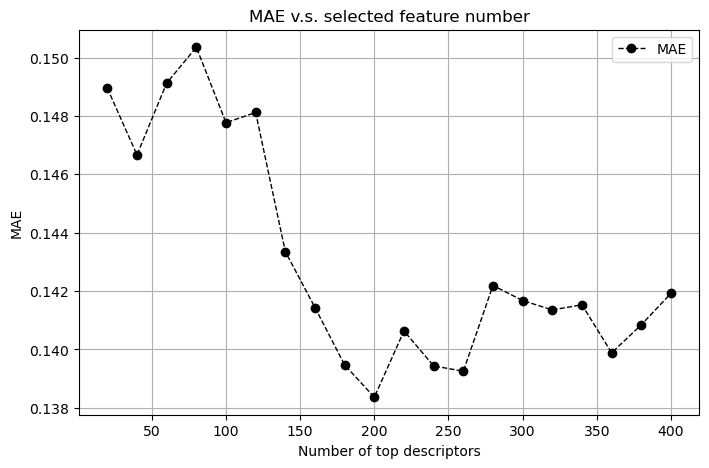

In [ ]:

plt.figure(figsize=(8,5))

plt.plot(
    results_df['n_features'],
    results_df['MAE'],
    marker='o',
    label='MAE',
    linestyle = '--', color = 'k', lw=1
)
plt.title("MAE v.s. selected feature number")
plt.xlabel('Number of top descriptors')
plt.ylabel('MAE')
plt.grid(True)
plt.legend()

plt.show()

In [23]:
# as a next set we want to select 200 top Dragon descriptors and perform SearchGrid
param_grid = {
    "n_estimators": [300, 800, 1200],
    "learning_rate": [0.02, 0.05],
    "max_depth": [2, 3, 4],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
    "reg_alpha": [0, 0.5, 2],
    "reg_lambda": [1, 5],
    "min_child_weight": [1, 3],
    "gamma": [0, 0.3]
}

In [24]:
top_200_features = importance.index[:200]
X200 = mX2_df[top_200_features]
print(X200.shape)

(288, 200)


In [25]:
grid = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:absoluteerror",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=4
)

grid.fit(X200, vY)

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 1.0], 'gamma': [0, 0.3], 'learning_rate': [0.02, 0.05], 'max_depth': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the co

In [28]:
print("Best CV MAE:", -grid.best_score_)
print()

print("Best parameters:")
for k, v in grid.best_params_.items():
    print(f"{k}: {v}")

Best CV MAE: 0.13252376931635307

Best parameters:
colsample_bytree: 1.0
gamma: 0
learning_rate: 0.05
max_depth: 2
min_child_weight: 3
n_estimators: 1200
reg_alpha: 0.5
reg_lambda: 5
subsample: 0.7


In [29]:
best_xgb_di = XGBRegressor(
    objective="reg:absoluteerror",
    colsample_bytree= 1.0,
    gamma=0,
    learning_rate= 0.05,
    max_depth=2,
    min_child_weight= 3,
    n_estimators= 1200,
    reg_alpha=0.5,
    reg_lambda=5,
    subsample=0.7,
    random_state=42,
    n_jobs=-1
)

In [30]:
vY_pred_best = cross_val_predict(estimator=best_xgb_di, X=X200, y=vY, cv=cv, n_jobs=-1, verbose=4)
mae_best = mean_absolute_error(vY, vY_pred_best)
print(mae_best)
r2_best = r2_score(vY, vY_pred_best)
print(r2_best)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


0.1325952033119069
0.3802731351590912


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    5.4s remaining:    8.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.5s finished


In [32]:
results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for n_features in range(20, 420, 20):

    top_features = importance.index[:n_features]

    X_subset = mX2_df[top_features]


    y_pred = cross_val_predict(
        best_xgb_di,
        X_subset,
        vY,
        cv=cv
    )

    mae = mean_absolute_error(vY, y_pred)
    r2 = r2_score(vY, y_pred)

    results.append({
        'n_features': n_features,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

,n_features,MAE,R2
0,20,0.150944,0.209823
1,40,0.147380,0.253946
2,60,0.144401,0.284373
3,80,0.147738,0.264448
4,100,0.146890,0.268409
5,120,0.147094,0.265847
6,140,0.139649,0.323278
7,160,0.138102,0.338286
8,180,0.135569,0.352737
9,200,0.137066,0.346885


In [33]:
results_df.sort_values('MAE')

,n_features,MAE,R2
8,180,0.135569,0.352737
14,300,0.135814,0.355696
10,220,0.135872,0.355618
18,380,0.136434,0.349307
12,260,0.136864,0.354505
9,200,0.137066,0.346885
17,360,0.137263,0.345125
11,240,0.137673,0.339754
16,340,0.137893,0.336584
7,160,0.138102,0.338286


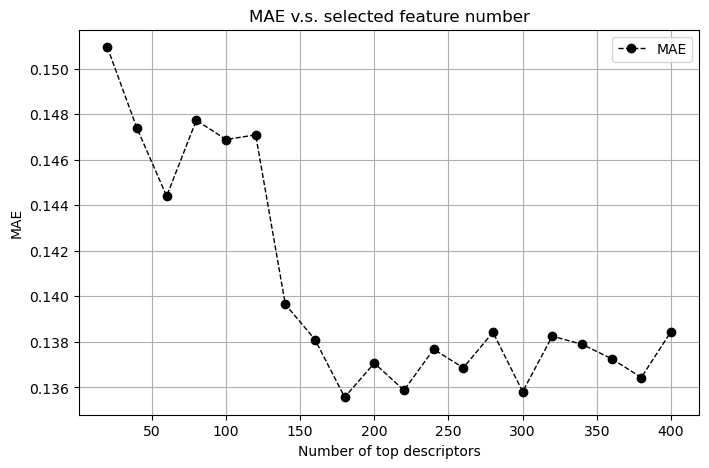

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df['n_features'],
    results_df['MAE'],
    marker='o',
    label='MAE',
    linestyle = '--', color = 'k', lw=1
)
plt.title("MAE v.s. selected feature number")
plt.xlabel('Number of top descriptors')
plt.ylabel('MAE')
plt.grid(True)
plt.legend()

plt.show()

In [35]:
top_180_features = importance.index[:180]
X180 = mX2_df[top_180_features]
print(X180.shape)

(288, 180)


In [38]:
vY_pred_180 = cross_val_predict(estimator=best_xgb_di, X=X180, y=vY, cv=cv, n_jobs=-1, verbose=4)
mae_180 = mean_absolute_error(vY, vY_pred_180)
print(mae_180)
r2_180 = r2_score(vY, vY_pred_180)
print(r2_180)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


0.1351127386631237
0.3659395154598649


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    4.1s remaining:    6.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.2s finished


In [39]:
# let's do umap visualization and see whether we have some clustering

import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.3,
    metric='euclidean',
    random_state=42
)

embedding = reducer.fit_transform(X180)

c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


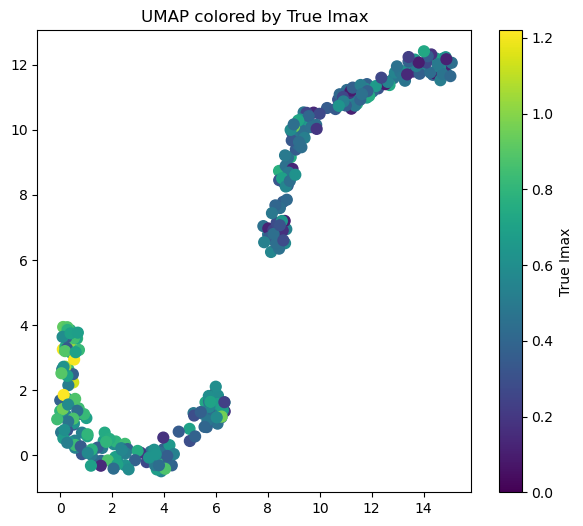

In [40]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=vY,
    cmap='viridis',
    s=60
)

plt.colorbar(sc,label="True Imax")

plt.title("UMAP colored by True Imax")
plt.show()